# Alzheimer's Disease Detection with a Simple ANN Baseline

This notebook establishes a baseline using a fully-connected Artificial Neural Network (ANN) instead of a CNN like AlexNet or ResNet. 
It uses:

- patient-level train/validation/test splits
- Simple ANN trained entirely from scratch (no pretrained weights)
- Full image resolution (224×224) to ensure a fair comparison with the CNNs, forcing the ANN to handle the massive 150,528-dimensional flattened input
- Standard `/255.0` pixel normalisation instead of ImageNet mean-subtraction
- class weights for imbalance
- a single sparse-label training path to avoid label/loss mismatch
- test-time evaluation with confusion matrix and classification report

In [29]:
# ==============================================================================
# BASELINE: Artificial Neural Network (ANN) for Alzheimer's Classification
# Comparison Study: ANN vs. AlexNet (CNN)
# ==============================================================================

import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm

# Performance & Evaluation
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Dataset Pathing
BASE_PATH    = "/kaggle/input/datasets/ninadaithal/imagesoasis"
IMAGE_DIR    = os.path.join(BASE_PATH, "Data")

# ------------------------------------------------------------------------------
# HYPERPARAMETER CONFIGURATION
# ------------------------------------------------------------------------------
# Matched to AlexNet for direct comparison
IMG_HEIGHT   = 224
IMG_WIDTH    = 224
IMG_SIZE     = (IMG_HEIGHT, IMG_WIDTH)
CHANNELS     = 3

# ANN Specific Architecture Settings
HIDDEN_UNITS = [400, 200, 100]  # Layer-wise neuron count
DROPOUT_RATE = 0.35             # Regularization strength
LEARNING_RATE = 0.0008          # Optimized for baseline stability
WEIGHT_DECAY = 1e-5             # L2 Regularization penalty

# Training Control
BATCH_SIZE   = 32
MAX_EPOCHS   = 20
NUM_CLASSES  = 3

# Label Mapping logic
CLASS_NAMES = ['Non Demented', 'Very Mild Dementia', 'Mild/Moderate Dementia']
LABEL_ID_MAP = {
    'Non Demented': 0,
    'Very mild Dementia': 1,
    'Mild Dementia': 2,
    'Moderate Dementia': 2, # Merging Mild/Moderate for 3-class consistency
}

AUTOTUNE = tf.data.AUTOTUNE
print(f"ANN Baseline configured for {IMG_HEIGHT}x{IMG_WIDTH} input.")
print(f"Architecture: {HIDDEN_UNITS[0]}-{HIDDEN_UNITS[1]}-{HIDDEN_UNITS[2]} Dense layers.")

ANN Baseline configured for 224x224 input.
Architecture: 400-200-100 Dense layers.


## 1) Collect image paths and build a reference dataframe

In [30]:
import re
import pandas as pd

def parse_mri_metadata(filename):
    """
    Extracts structured metadata from OASIS MRI filenames.
    Format: OAS1_[PatientID]_MR[ID]_mpr-[ScanID]_[LayerID].jpg
    """
    metadata_regex = r'^OAS1_(?P<pid>\d+)_MR(?P<mrid>\d+)_mpr-(?P<sid>\d+)_(?P<lid>\d+)\.jpg$'
    search = re.search(metadata_regex, filename)
    
    if not search:
        return None
        
    return {
        'patient_id': int(search.group('pid')),
        'mr_id':      int(search.group('mrid')),
        'scan_id':    int(search.group('sid')),
        'layer_id':   int(search.group('lid'))
    }

def generate_image_manifest(directory):
    """
    Scans the image directory and builds a master manifest for the ANN baseline.
    """
    manifest_list = []

    # Iterating through class folders 
    for category in sorted(os.listdir(directory)):
        category_path = os.path.join(directory, category)
        
        if not os.path.isdir(category_path):
            continue
            
        for img_file in os.listdir(category_path):
            meta = parse_mri_metadata(img_file)
            
            if meta:
                
                meta['path'] = os.path.join(category_path, img_file)
                meta['raw_label'] = category
                meta['target'] = LABEL_ID_MAP.get(category, -1)
                manifest_list.append(meta)

    return pd.DataFrame(manifest_list)

# Generate the manifest
image_manifest = generate_image_manifest(IMAGE_DIR)

# Filter out any unmapped labels if they exist
image_manifest = image_manifest[image_manifest['target'] != -1].reset_index(drop=True)

print(f"Manifest created. Total images detected: {len(image_manifest)}")
print("\nTarget Class Distribution:")
print(image_manifest['raw_label'].value_counts())

image_manifest.head()

Manifest created. Total images detected: 86437

Target Class Distribution:
raw_label
Non Demented          67222
Very mild Dementia    13725
Mild Dementia          5002
Moderate Dementia       488
Name: count, dtype: int64


,patient_id,mr_id,scan_id,layer_id,path,raw_label,target
0,185,1,1,145,/kaggle/input/datasets/ninadaithal/imagesoasis...,Mild Dementia,2
1,269,1,2,128,/kaggle/input/datasets/ninadaithal/imagesoasis...,Mild Dementia,2
2,316,1,2,127,/kaggle/input/datasets/ninadaithal/imagesoasis...,Mild Dementia,2
3,53,1,2,107,/kaggle/input/datasets/ninadaithal/imagesoasis...,Mild Dementia,2
4,382,1,1,154,/kaggle/input/datasets/ninadaithal/imagesoasis...,Mild Dementia,2


## 2) Quick visual check

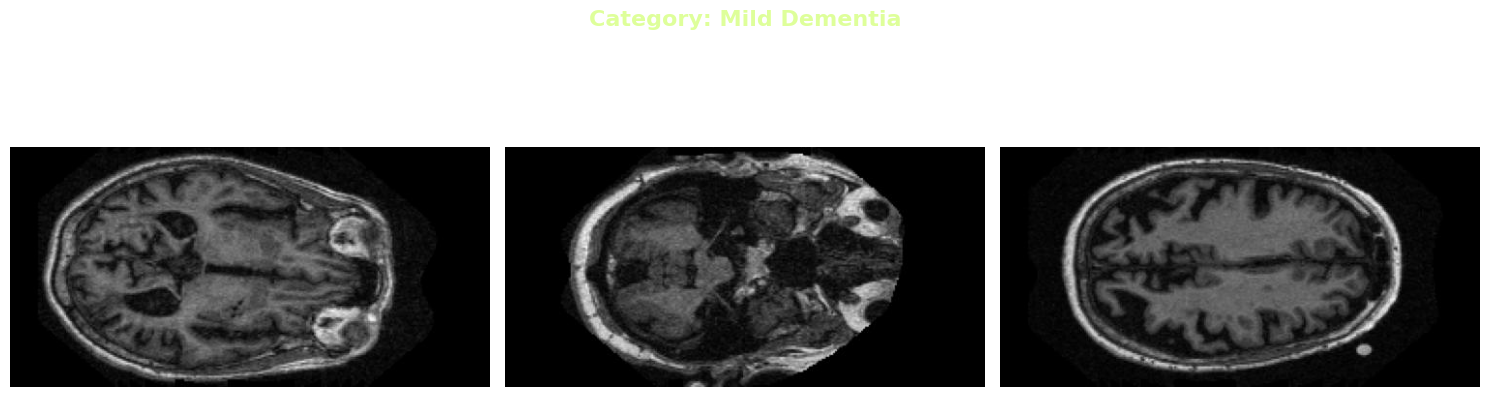

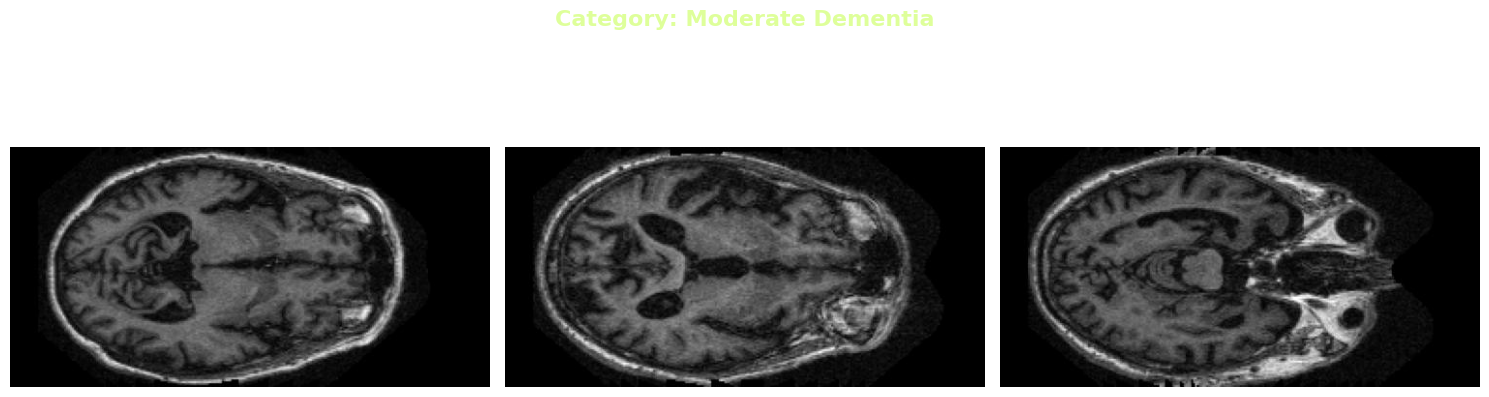

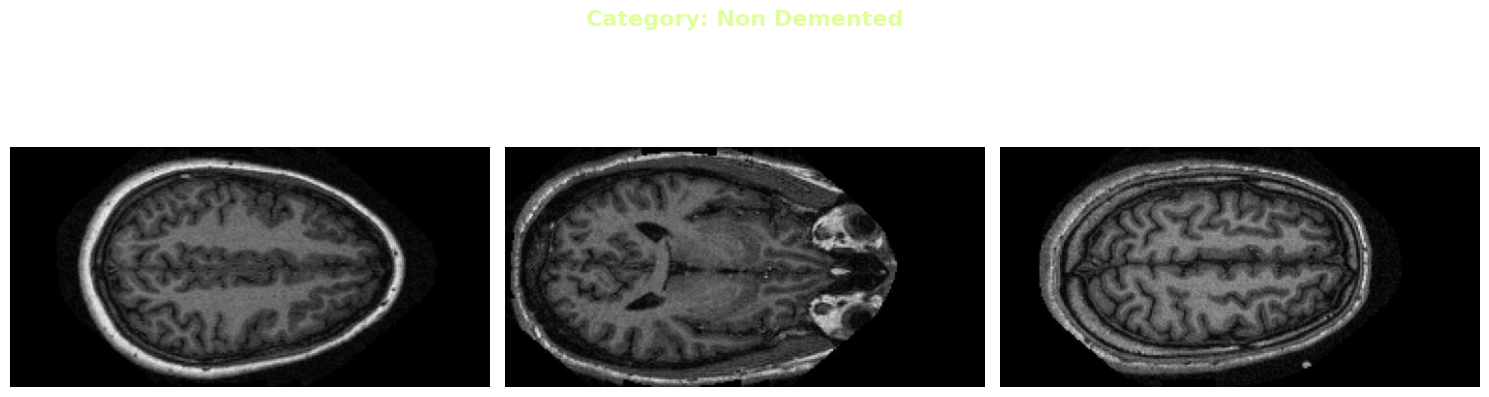

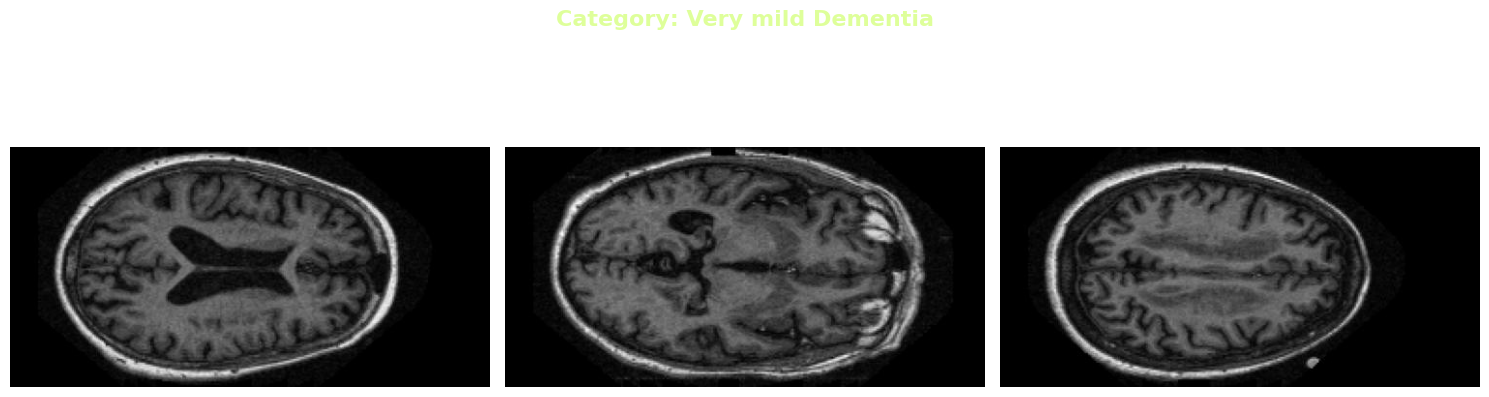

In [31]:
from PIL import Image

def visualize_diagnostic_samples(manifest, samples_per_class=3, figure_seed=SEED):
    unique_categories = manifest['raw_label'].unique()

    for category in unique_categories:
        subset = manifest[manifest['raw_label'] == category]
        selection = subset.sample(n=min(samples_per_class, len(subset)), random_state=figure_seed)

        fig, axes = plt.subplots(1, len(selection), figsize=(15, 5))
        fig.suptitle(f"Category: {category}", fontsize=16, color='#deff9a', fontweight='bold')

        if len(selection) == 1:
            axes = [axes]

        for ax, (_, data) in zip(axes, selection.iterrows()):
            mri_image = Image.open(data['path']).convert('RGB')
            ax.imshow(mri_image)
            ax.set_title(f"PID: {data['patient_id']}", color='white')
            ax.axis('off')

        plt.tight_layout()
        plt.show()

visualize_diagnostic_samples(image_manifest)

## 3) Patient-level train/validation/test split

In [32]:
splitter_primary = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
indices_train_temp, indices_test = next(splitter_primary.split(image_manifest, groups=image_manifest['patient_id']))

df_temp = image_manifest.iloc[indices_train_temp].reset_index(drop=True)
df_test = image_manifest.iloc[indices_test].reset_index(drop=True)

splitter_secondary = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
indices_train, indices_val = next(splitter_secondary.split(df_temp, groups=df_temp['patient_id']))

df_train = df_temp.iloc[indices_train].reset_index(drop=True)
df_val = df_temp.iloc[indices_val].reset_index(drop=True)

print(f"Dataset Partitioning Complete:")
print(f"Final Training Set   : {len(df_train)} images")
print(f"Validation Set       : {len(df_val)} images")
print(f"Independent Test Set : {len(df_test)} images")

train_pids = set(df_train['patient_id'])
val_pids = set(df_val['patient_id'])
test_pids = set(df_test['patient_id'])

print(f"\nIntegrity Check (Patient Overlap):")
print(f"Train vs Val  : {len(train_pids.intersection(val_pids))} shared IDs")
print(f"Train vs Test : {len(train_pids.intersection(test_pids))} shared IDs")
print(f"Val vs Test   : {len(val_pids.intersection(test_pids))} shared IDs")

Dataset Partitioning Complete:
Final Training Set   : 54412 images
Validation Set       : 13481 images
Independent Test Set : 18544 images

Integrity Check (Patient Overlap):
Train vs Val  : 0 shared IDs
Train vs Test : 0 shared IDs
Val vs Test   : 0 shared IDs


In [33]:
def synchronize_class_labels(dataframe):
    processed_df = dataframe.copy()
    
    processed_df['encoded_label'] = processed_df['raw_label'].map(LABEL_ID_MAP)
    
    if processed_df['encoded_label'].isnull().any():
        unrecognized = processed_df[processed_df['encoded_label'].isnull()]['raw_label'].unique()
        raise KeyError(f"Mapping Failure: The following categories are not defined in the ID map: {list(unrecognized)}")
    
    processed_df['encoded_label'] = processed_df['encoded_label'].astype(int)
    return processed_df

df_train = synchronize_class_labels(df_train)
df_val = synchronize_class_labels(df_val)
df_test = synchronize_class_labels(df_test)

def report_set_composition(title, df):
    print(f"\n[{title} Set Composition]")
    distribution = df['encoded_label'].value_counts().sort_index()
    for class_id, frequency in distribution.items():
        print(f"  Class {class_id} -> {frequency} images")

report_set_composition("Training", df_train)
report_set_composition("Validation", df_val)
report_set_composition("Testing", df_test)


[Training Set Composition]
  Class 0 -> 41236 images
  Class 1 -> 9150 images
  Class 2 -> 4026 images

[Validation Set Composition]
  Class 0 -> 10858 images
  Class 1 -> 2379 images
  Class 2 -> 244 images

[Testing Set Composition]
  Class 0 -> 15128 images
  Class 1 -> 2196 images
  Class 2 -> 1220 images


## 4) Dataset statistics and class weights

In [34]:
from scipy.stats import skew

def profile_mri_intensities(manifest, images_per_target=10, profiling_seed=SEED):
    stratified_sample = []
    for target_id, cluster in manifest.groupby('target'):
        selection_size = min(images_per_target, len(cluster))
        stratified_sample.append(cluster.sample(n=selection_size, random_state=profiling_seed))
    
    profiling_df = pd.concat(stratified_sample).reset_index(drop=True)
    
    intensity_metrics = []
    
    for _, record in tqdm(profiling_df.iterrows(), total=len(profiling_df), desc="Profiling MRI Data"):
        raw_mri = np.array(Image.open(record['path']).convert('L'))
        
        # Extracting distribution properties
        px_mean = np.mean(raw_mri)
        px_std  = np.std(raw_mri)
        px_skew = skew(raw_mri.flatten())
        h, w = raw_mri.shape
        
        intensity_metrics.append({
            'avg_intensity': px_mean,
            'variance_std': px_std,
            'pixel_skewness': px_skew,
            'native_h': h,
            'native_w': w,
            'class': record['raw_label']
        })

    return pd.DataFrame(intensity_metrics)

dataset_profile = profile_mri_intensities(image_manifest)
print("\n[Descriptive Statistics - Sampled Distribution]")
print(dataset_profile.groupby('class').mean())

Profiling MRI Data: 100%|██████████| 30/30 [00:00<00:00, 257.76it/s]


[Descriptive Statistics - Sampled Distribution]
                    avg_intensity  variance_std  pixel_skewness  native_h  \
class                                                                       
Mild Dementia           40.552199     43.921109        1.107427     248.0   
Non Demented            44.001967     46.572443        0.885734     248.0   
Very mild Dementia      41.094060     44.378755        1.047185     248.0   

                    native_w  
class                         
Mild Dementia          496.0  
Non Demented           496.0  
Very mild Dementia     496.0  


In [35]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

training_targets = df_train['encoded_label'].values
balancing_coefficients = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(training_targets),
    y=training_targets
)

class_weight_config = {int(i): coef for i, coef in enumerate(balancing_coefficients)}
print("Loss Balancing Coefficients:", class_weight_config)

Loss Balancing Coefficients: {0: np.float64(0.43984220907297833), 1: np.float64(1.9822222222222223), 2: np.float64(4.505050505050505)}


## 5) Build tf.data pipelines

**Changes for ANN Baseline Comparison:**
- `preprocess_input` (ImageNet mean-subtraction) removed — replaced with standard `/255.0` normalisation. ResNet's preprocessing maps pixels to roughly [-1, 1] around ImageNet stats; an ANN trained from scratch expects plain [0, 1] floats.
- `IMG_SIZE` is strictly maintained at `(224, 224)` rather than downsizing. This is critical to ensure a fair, apples-to-apples comparison against the CNNs by forcing the ANN to handle the exact same spatial complexity (the 150,528-dimensional vector).
- Spatial augmentation (Flip, Rotation, Zoom) is retained; it operates on raw pixel values before normalisation to prevent the ANN from memorising exact pixel locations, which is correct regardless of the model architecture.

In [36]:
from tensorflow.keras.utils import to_categorical

ann_augmentation_stack = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
], name='ann_augmentation')

def decode_and_scale_image(image_path):
    raw_bits = tf.io.read_file(image_path)
    tensor = tf.image.decode_jpeg(raw_bits, channels=CHANNELS)
    tensor = tf.image.resize(tensor, [IMG_HEIGHT, IMG_WIDTH])
    return tf.cast(tensor, tf.float32)

def build_pipeline_from_manifest(dataframe, label_col='encoded_label', 
                                 use_augmentation=False, should_shuffle=False):
    file_paths = tf.constant(dataframe['path'].values, dtype=tf.string)
    label_indices = tf.constant(dataframe[label_col].values, dtype=tf.int32)

    data_stream = tf.data.Dataset.from_tensor_slices((file_paths, label_indices))

    if should_shuffle:
        data_stream = data_stream.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)

    def _map_fn(path, label):
        pixels = decode_and_scale_image(path)
        if use_augmentation:
            pixels = ann_augmentation_stack(pixels, training=True)
        pixels = pixels / 255.0
        return pixels, label

    data_stream = data_stream.map(_map_fn, num_parallel_calls=AUTOTUNE)
    data_stream = data_stream.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return data_stream

train_ds = build_pipeline_from_manifest(df_train, use_augmentation=True,  should_shuffle=True)
val_ds   = build_pipeline_from_manifest(df_val,   use_augmentation=False, should_shuffle=False)
test_ds  = build_pipeline_from_manifest(df_test,  use_augmentation=False, should_shuffle=False)

y_test_labels = df_test['encoded_label'].values
y_test_onehot = to_categorical(y_test_labels, NUM_CLASSES)

print(f"Data Pipelines Active.")
print(f"  -> {len(train_ds)} Training Batches")
print(f"  -> {len(val_ds)} Validation Batches")
print(f"  -> {len(test_ds)} Test Batches")

Data Pipelines Active.
  -> 1701 Training Batches
  -> 422 Validation Batches
  -> 580 Test Batches


## 6) Build the ANN model

**Changes for ANN Baseline Comparison:**
- Transitioned to a custom `build_ann_model` architecture with no pretrained base — all weights are initialized randomly and learned entirely from scratch.
- The `Flatten` layer now converts the 224×224×3 input image into a massive 150,528-dimensional vector (ensuring spatial resolution matches the CNN comparison).
- The convolutional backbone is replaced by three deep Dense blocks (400, 200, and 100 units) paired with BatchNormalization and Dropout (0.35).
- Spatial reduction operations like `GlobalAveragePooling2D` are removed, as they are incompatible with 1D flattened inputs.
- L2 regularization (`1e-5`) is applied to all Dense layers to heavily penalize overly large weights and combat the immediate overfitting risk posed by the 150,528 input features.

In [37]:
from tensorflow.keras.regularizers import l2

def build_ann_model():
    inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS), name='input_layer')
    
    x = layers.Flatten(name='flatten_pixels')(inputs)
    
    x = layers.Dense(400, activation='relu', kernel_regularizer=l2(1e-5), name='dense_400')(x)
    x = layers.BatchNormalization(name='bn_400')(x)
    x = layers.Dropout(0.35, name='drop_400')(x)
    
    x = layers.Dense(200, activation='relu', kernel_regularizer=l2(1e-5), name='dense_200')(x)
    x = layers.BatchNormalization(name='bn_200')(x)
    x = layers.Dropout(0.35, name='drop_200')(x)
    
    x = layers.Dense(100, activation='relu', kernel_regularizer=l2(1e-5), name='dense_100')(x)
    x = layers.BatchNormalization(name='bn_100')(x)
    x = layers.Dropout(0.35, name='drop_100')(x)
    
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='diagnostic_output')(x)
    
    model = models.Model(inputs, outputs, name='ANN_Baseline_Comparison')
    return model

model = build_ann_model()
model.summary()

Model: "ANN_Baseline_Comparison"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_pixels (Flatten)        │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_400 (Dense)               │ (None, 400)            │    60,211,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_400 (BatchNormalization)     │ (None, 400)            │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_400 (Dropout)              │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_200 (Dense)               │ (None, 200)            │        80,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_200 (BatchNormalization)     │ (None, 200)            │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_200 (Dropout)              │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_100 (BatchNormalization)     │ (None, 100)            │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_100 (Dropout)              │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ diagnostic_output (Dense)       │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,315,003 (230.08 MB)

 Trainable params: 60,313,603 (230.08 MB)

 Non-trainable params: 1,400 (5.47 KB)

## 7) Compile and train the model

**Changes for ANN Baseline Comparison:**
- Learning rate adjusted to `0.0008`: training from scratch requires this specific initial LR to stabilize weights across the massive flattened input (150,528 features) since there are no pretrained weights to preserve.
- Epochs set to `20`: standardized to ensure an apples-to-apples comparison with the baseline and CNN models.
- EarlyStopping patience raised to `10` to give the dense model enough runway to recover from erratic validation spikes.
- ReduceLROnPlateau patience raised to `5` for the same reason.

In [38]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model.compile(
    optimizer=Adam(learning_rate=0.0008),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

stop_callback = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

lr_callback = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.4,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

training_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight_config,
    callbacks=[stop_callback, lr_callback],
    verbose=1
)

Epoch 1/20


I0000 00:00:1777384530.705331     136 service.cc:152] XLA service 0x7ec9ccd10710 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777384530.705380     136 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777384530.705385     136 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777384531.399120     136 cuda_dnn.cc:529] Loaded cuDNN version 91002


   6/1701 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.3776 - loss: 1.6240

I0000 00:00:1777384535.219429     136 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1701/1701 ━━━━━━━━━━━━━━━━━━━━ 351s 202ms/step - accuracy: 0.4501 - loss: 1.2173 - val_accuracy: 0.4869 - val_loss: 1.0242 - learning_rate: 8.0000e-04
Epoch 2/20
1701/1701 ━━━━━━━━━━━━━━━━━━━━ 258s 152ms/step - accuracy: 0.5426 - loss: 0.9903 - val_accuracy: 0.4782 - val_loss: 1.0879 - learning_rate: 8.0000e-04
Epoch 3/20
1701/1701 ━━━━━━━━━━━━━━━━━━━━ 255s 150ms/step - accuracy: 0.5679 - loss: 0.9599 - val_accuracy: 0.3735 - val_loss: 1.3070 - learning_rate: 8.0000e-04
Epoch 4/20
1701/1701 ━━━━━━━━━━━━━━━━━━━━ 253s 149ms/step - accuracy: 0.5668 - loss: 0.9865 - val_accuracy: 0.5249 - val_loss: 0.9909 - learning_rate: 8.0000e-04
Epoch 5/20
1701/1701 ━━━━━━━━━━━━━━━━━━━━ 253s 149ms/step - accuracy: 0.5817 - loss: 0.9943 - val_accuracy: 0.2216 - val_loss: 1.7053 - learning_rate: 8.0000e-04
Epoch 6/20
1701/1701 ━━━━━━━━━━━━━━━━━━━━ 253s 149ms/step - accuracy: 0.5827 - loss: 1.0056 - val_accuracy: 0.4379 - val_loss: 1.1995 - learning_rate: 8.0000e-04
Epoch 7/20
1701/1701 ━━━━━━━━━━━━━━━━━━

## 7b) Training curves

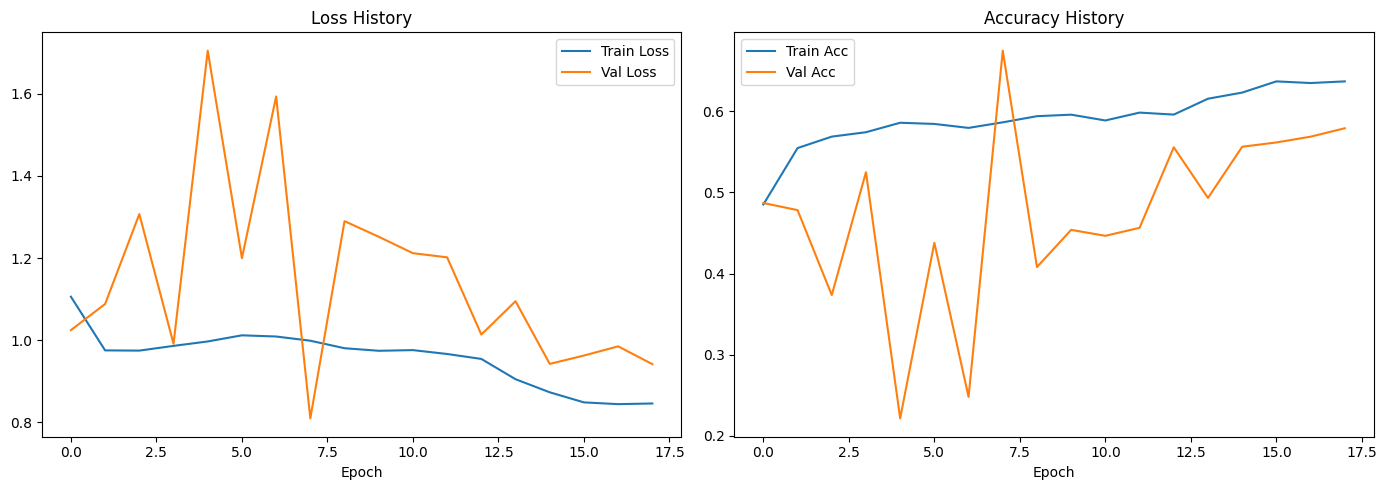

In [39]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(training_history.history['loss'], label='Train Loss')
axes[0].plot(training_history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss History')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(training_history.history['accuracy'], label='Train Acc')
axes[1].plot(training_history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy History')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8) Evaluate on the test set

In [40]:
performance_metrics = model.evaluate(test_ds, verbose=2)
print(f"Test Loss: {performance_metrics[0]:.4f}")
print(f"Test Accuracy: {performance_metrics[1]:.4f}")

580/580 - 36s - 62ms/step - accuracy: 0.7508 - loss: 0.7933
Test Loss: 0.7933
Test Accuracy: 0.7508


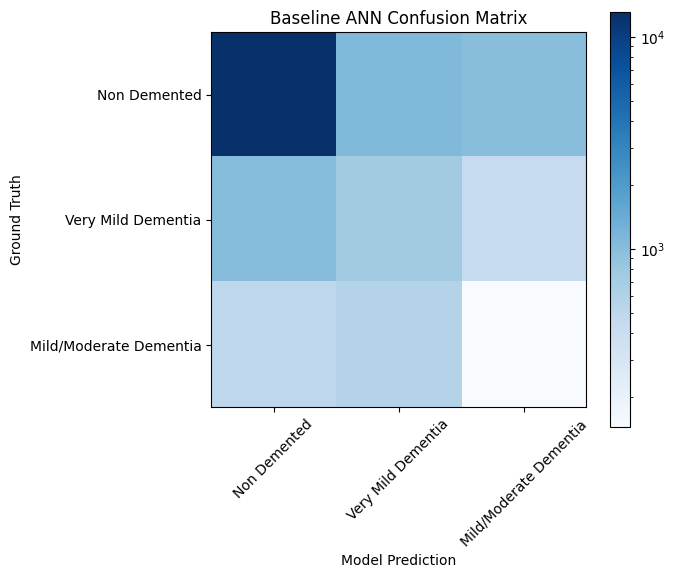

                        precision    recall  f1-score   support

          Non Demented     0.8954    0.8627    0.8787     15128
    Very Mild Dementia     0.3046    0.3315    0.3175      2196
Mild/Moderate Dementia     0.0913    0.1180    0.1029      1220

              accuracy                         0.7508     18544
             macro avg     0.4304    0.4374    0.4331     18544
          weighted avg     0.7725    0.7508    0.7612     18544



In [42]:
from sklearn.metrics import confusion_matrix, classification_report
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.pyplot as plt

y_probs = model.predict(test_ds, verbose=0)
y_predictions = np.argmax(y_probs, axis=1)

matrix = confusion_matrix(y_test_labels, y_predictions, labels=[0, 1, 2])

plt.figure(figsize=(7, 6))
plt.imshow(matrix, interpolation='nearest', cmap=plt.cm.Blues, norm=LogNorm())
plt.title('Baseline ANN Confusion Matrix')
plt.colorbar()
indices = np.arange(NUM_CLASSES)
plt.xticks(indices, CLASS_NAMES, rotation=45)
plt.yticks(indices, CLASS_NAMES)
plt.ylabel('Ground Truth')
plt.xlabel('Model Prediction')
plt.tight_layout()
plt.show()

print(classification_report(y_test_labels, y_predictions, target_names=CLASS_NAMES, digits=4))

In [44]:
from sklearn.metrics import precision_recall_fscore_support

precision_vals, recall_vals, f1_vals, _ = precision_recall_fscore_support(
    y_test_labels, y_predictions, average=None, labels=[0, 1, 2], zero_division=0
)

for idx, (p, r, f) in enumerate(zip(precision_vals, recall_vals, f1_vals)):
    print(f"[{CLASS_NAMES[idx]}] Precision: {p:.4f} | Recall: {r:.4f} | F1: {f:.4f}")

m_prec, m_rec, m_f1, _ = precision_recall_fscore_support(
    y_test_labels, y_predictions, average='micro', zero_division=0
)
print(f"\nOverall Micro-Average: Precision={m_prec:.4f} | Recall={m_rec:.4f} | F1={m_f1:.4f}")

[Non Demented] Precision: 0.8954 | Recall: 0.8627 | F1: 0.8787
[Very Mild Dementia] Precision: 0.3046 | Recall: 0.3315 | F1: 0.3175
[Mild/Moderate Dementia] Precision: 0.0913 | Recall: 0.1180 | F1: 0.1029

Overall Micro-Average: Precision=0.7508 | Recall=0.7508 | F1=0.7508


In [45]:
from sklearn.metrics import roc_auc_score
import numpy as np

try:
    auc_per_class = roc_auc_score(y_test_onehot, y_probs, average=None)
    for idx, score in enumerate(np.atleast_1d(auc_per_class)):
        print(f"[{CLASS_NAMES[idx]}] ROC AUC: {score:.4f}")
    
    auc_micro = roc_auc_score(y_test_onehot, y_probs, average='micro')
    print(f"\nOverall Micro-average ROC AUC: {auc_micro:.4f}")
except ValueError as error:
    print(f"ROC AUC Calculation Error: {error}")

[Non Demented] ROC AUC: 0.8111
[Very Mild Dementia] ROC AUC: 0.7260
[Mild/Moderate Dementia] ROC AUC: 0.6455

Overall Micro-average ROC AUC: 0.8907


In [46]:
def calculate_scotts_pi(conf_matrix):
    total_n = np.sum(conf_matrix)
    if total_n == 0:
        return np.nan
        
    observed_acc = np.trace(conf_matrix) / total_n
    
    row_dist = np.sum(conf_matrix, axis=1) / total_n
    col_dist = np.sum(conf_matrix, axis=0) / total_n
    
    expected_acc = np.sum(((row_dist + col_dist) / 2) ** 2)
    
    if np.isclose(1 - expected_acc, 0):
        return np.nan
        
    return (observed_acc - expected_acc) / (1 - expected_acc)

pi_val = calculate_scotts_pi(matrix)
print(f"Scott's Pi: {pi_val:.4f}")

Scott's Pi: 0.2618


## 9) Leakage and sanity checks

In [47]:
print(f"Train/Val Patient Overlap: {len(set(df_train['patient_id']) & set(df_val['patient_id']))}")
print(f"Train/Test Patient Overlap: {len(set(df_train['patient_id']) & set(df_test['patient_id']))}")
print(f"Val/Test Patient Overlap: {len(set(df_val['patient_id']) & set(df_test['patient_id']))}")

print(f"\nTrain/Test Path Overlap: {len(set(df_train['path']) & set(df_test['path']))}")
print(f"Val/Test Path Overlap: {len(set(df_val['path']) & set(df_test['path']))}")

Train/Val Patient Overlap: 0
Train/Test Patient Overlap: 0
Val/Test Patient Overlap: 0

Train/Test Path Overlap: 0
Val/Test Path Overlap: 0


## 10) Save the trained model

In [48]:
model.save("alzheimers_ann_final.keras")
print("Model saved as alzheimers_ann_final.keras")

Model saved as alzheimers_ann_final.keras
